# Teaching Assistant Information

### 📌 Problem Statement

Teaching Assistants (TAs) play a critical role in enhancing the quality of education by supporting instructors and facilitating student learning. Evaluating TA performance is essential for maintaining academic standards and improving instructional quality. However, manual evaluation processes can be subjective, time-consuming, and inconsistent across evaluators.

The Teaching Assistant Evaluation Dataset contains historical evaluation data of TAs across multiple semesters at the University of Wisconsin–Madison. Each TA assignment is assessed based on factors such as language proficiency, course instructor, course type, semester, and class size. The evaluation scores are categorized into three performance levels: Low, Medium, and High.

The challenge is to automatically predict the performance category of a Teaching Assistant using these attributes, framing the problem as a supervised multi-class classification task.

### Objectives

The primary objectives of this study are:

To perform Exploratory Data Analysis (EDA)

Understand the distribution and characteristics of the dataset

Identify relationships between TA attributes and performance levels

To preprocess the dataset for machine learning

Encode categorical variables

Prepare features and target variables

To build and evaluate multiple classification models

Train different machine learning algorithms

Compare their performance using standard evaluation metrics

To identify the most suitable model

Recommend a robust and accurate model for predicting TA performance

To analyze challenges and limitations

Address issues such as small dataset size and categorical dominance

In [4]:
import numpy as np
import pandas as pd

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [2]:
df = pd.read_csv("teaching_assistance.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   1       150 non-null    int64
 1   23      150 non-null    int64
 2   3       150 non-null    int64
 3   1.1     150 non-null    int64
 4   19      150 non-null    int64
 5   3.1     150 non-null    int64
dtypes: int64(6)
memory usage: 7.2 KB


In [3]:
df.head()

,1,23,3,1.1,19,3.1
0,2,15,3,1,17,3
1,1,23,3,2,49,3
2,1,5,2,2,33,3
3,2,7,11,2,55,3
4,2,23,3,1,20,3


In [6]:
df.columns = [
    "Native_teacher",
    "Instructor",
    "Course",
    "Semester",
    "Class_size",
    "Performance"
]

df.head()

,Native_teacher,Instructor,Course,Semester,Class_size,Performance
0,2,15,3,1,17,3
1,1,23,3,2,49,3
2,1,5,2,2,33,3
3,2,7,11,2,55,3
4,2,23,3,1,20,3


In [7]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Native_teacher  150 non-null    int64
 1   Instructor      150 non-null    int64
 2   Course          150 non-null    int64
 3   Semester        150 non-null    int64
 4   Class_size      150 non-null    int64
 5   Performance     150 non-null    int64
dtypes: int64(6)
memory usage: 7.2 KB


,Native_teacher,Instructor,Course,Semester,Class_size,Performance
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,1.813333,13.580000,8.140000,1.853333,27.926667,2.013333
std,0.390949,6.805318,7.034937,0.354958,12.916405,0.819123
min,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000
25%,2.000000,8.000000,3.000000,2.000000,19.000000,1.000000
50%,2.000000,13.000000,4.500000,2.000000,27.000000,2.000000
75%,2.000000,20.000000,15.000000,2.000000,37.000000,3.000000
max,2.000000,25.000000,26.000000,2.000000,66.000000,3.000000


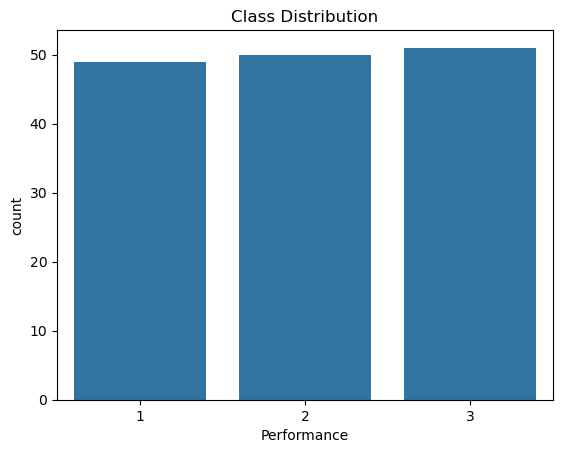

In [8]:
sns.countplot(x="Performance", data=df)
plt.title("Class Distribution")
plt.show()

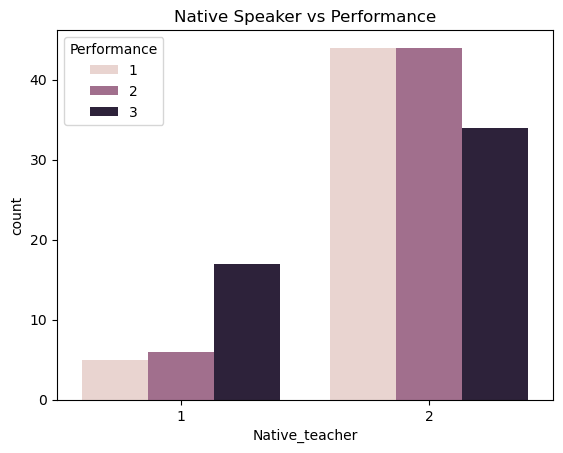

In [9]:
sns.countplot(x="Native_teacher", hue="Performance", data=df)
plt.title("Native Speaker vs Performance")
plt.show()

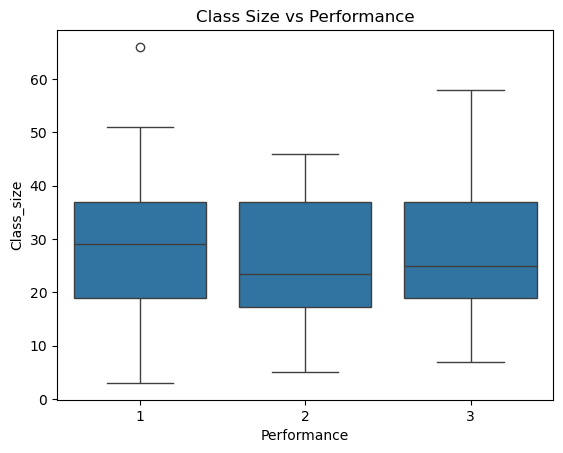

In [10]:
sns.boxplot(x="Performance", y="Class_size", data=df)
plt.title("Class Size vs Performance")
plt.show()


In [18]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categorical_cols = ["Native_teacher", "Instructor", "Course", "Semester"]
numerical_cols = ["Class_size"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ]
)

In [19]:
le = LabelEncoder()

for col in ["Native_teacher", "Instructor", "Course", "Semester", "Performance"]:
    df[col] = le.fit_transform(df[col])

In [20]:
X = df.drop("Performance", axis=1)
y = df["Performance"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Models Used               Model	Reason

#### Logistic Regression  -  Baseline multi-class classifier

#### Decision Tree  -  Captures non-linear patterns

#### Random Forest  -  Reduces Overfitting

#### SVM  -  Strong for small datasets

In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

In [22]:
pd.DataFrame.from_dict(results, orient="index", columns=["Accuracy"]).sort_values(by="Accuracy", ascending=False)

,Accuracy
Logistic Regression,0.600000
Random Forest,0.566667
Decision Tree,0.533333
SVM,0.433333


In [23]:
logreg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        multi_class="multinomial",
        solver="lbfgs"
    ))
])

logreg_pipeline.fit(X_train, y_train)
y_pred = logreg_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.43333333333333335
              precision    recall  f1-score   support

           0       0.40      0.40      0.40        10
           1       0.42      0.50      0.45        10
           2       0.50      0.40      0.44        10

    accuracy                           0.43        30
   macro avg       0.44      0.43      0.43        30
weighted avg       0.44      0.43      0.43        30



In [24]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    logreg_pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("CV Accuracy:", cv_scores.mean())


CV Accuracy: 0.5866666666666667


In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__C": [0.01, 0.1, 1, 5, 10]
}

grid = GridSearchCV(
    logreg_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)


Best Params: {'classifier__C': 10}
Best CV Accuracy: 0.5833333333333334


In [26]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))


RF Accuracy: 0.6


In [27]:
from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

gb_pipeline.fit(X_train, y_train)
print("GB Accuracy:", accuracy_score(y_test, gb_pipeline.predict(X_test)))


GB Accuracy: 0.5333333333333333
